# Mode-by-mode SVD compression for LISA MBHB waveforms — a playground

This notebook lets you experiment with how to compress broadband multimode LISA
massive-black-hole-binary (MBHB) waveforms for DINGO, and **why the naive complex-strain
SVD needs a huge basis.**

It uses a self-contained *toy* frequency-domain multimode model (no `lisabeta`/`dingo`
dependency) so you can run it anywhere and tweak the knobs. The toy reproduces the one
feature that matters: a frequency-domain phase that **winds through ~10^3 rad and shifts
strongly across the prior**, exactly what defeats a linear SVD.

### Three things this notebook demonstrates

1. **Raw complex-strain SVD is hard.** `A·e^{iΨ}` needs hundreds of basis vectors.
2. **Heterodyning by a *fixed* reference does NOTHING for SVD.** Multiplying every
   waveform by `e^{-iΨ_fid(f)}` is a unitary op on the frequency axis, and SVD
   reconstruction error is invariant under it. (A surprising and important point — it's
   why relative-binning's reference trick is *not* the same as helping the SVD.)
3. **Separate amplitude + unwrapped-phase SVD is the real win.** The unwrapped phase is
   low-rank in the parameters (a few separable PN terms), so ~6–8 components per mode
   reach machine precision. This is option *1a* from our discussion — and it is exactly
   the option that forces "reconstruct each mode before summing", because `e^{iΨ}` is
   nonlinear.

> **Caveat baked into the toy:** waveforms are evaluated *analytically on a common grid*,
> so there is **no interpolation error** here — what you see is purely SVD truncation /
> representation power. That isolates the question we care about.


In [1]:
import numpy as np
import matplotlib
matplotlib.use("Agg")  # remove this line for interactive plots
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)
MSUN_S = 4.925491025543576e-6  # GM_sun / c^3 in seconds
MODES = [(2, 2), (2, 1), (3, 3), (4, 4)]


## 1. Toy multimode MBHB model (amplitude / phase per mode)

Each mode `(l,m)` is returned as `(amplitude[f], phase[f])` — the lisabeta-native
representation. The phase is dominated by the Newtonian chirp term
`Ψ ∝ (π 𝓜 f)^{-5/3}` (the big winder), with a 1PN/1.5PN spin correction so that the
phase shape depends on mass ratio and spin. Higher modes wind at ~`(m/2)×` the (2,2) rate.


In [2]:
def mode_amp_coeff(l, m, inc):
    c = {(2, 2): 1.0, (2, 1): 0.30, (3, 3): 0.18, (4, 4): 0.08}[(l, m)]
    s, co = np.sin(inc), np.cos(inc)
    shape = {(2, 2): (1 + co**2) / 2, (2, 1): s, (3, 3): s, (4, 4): s**2}[(l, m)]
    return c * np.abs(shape)

def chirp_to_total(Mc, q):
    eta = q / (1 + q) ** 2
    return Mc / eta ** 0.6, eta

def f_ring(m, M_s):
    f_isco = 1.0 / (6 ** 1.5 * np.pi * M_s)
    return (m / 2.0) * 2.0 * f_isco

def intrinsic_orbital_phase(f, Mc, M, eta, chi_eff):
    Mc_s, M_s = Mc * MSUN_S, M * MSUN_S
    v = (np.pi * M_s * f) ** (1.0 / 3.0)
    psi0 = (3.0 / 128.0) * (np.pi * Mc_s * f) ** (-5.0 / 3.0)
    psi_corr = psi0 * (v**2 * (3715.0 / 756.0 + 55.0 / 9.0 * eta)
                       - v**3 * (16.0 * np.pi - 4.0 * np.pi * chi_eff * (1.0 + eta)))
    return psi0 + psi_corr

def generate_modes(p, f):
    # Return {(l,m): (amp[f], phase[f])} on common grid f. Analytic => no interp error.
    M, eta = chirp_to_total(p["Mc"], p["q"])
    M_s, Mc_s = M * MSUN_S, p["Mc"] * MSUN_S
    chi_eff = (p["chi1"] + p["q"] * p["chi2"]) / (1 + p["q"])
    psi_orb = intrinsic_orbital_phase(f, p["Mc"], M, eta, chi_eff)
    out = {}
    for (l, m) in MODES:
        merger = 0.4 * (l - 2) * np.tanh(f / f_ring(m, M_s))      # mode-specific RD phase
        phase = (m / 2.0) * psi_orb + 2 * np.pi * f * p["tc"] + merger
        amp = mode_amp_coeff(l, m, p["inc"]) * Mc_s ** (5.0/6.0) * f ** (-7.0/6.0)
        amp = amp / np.sqrt(1.0 + (f / f_ring(m, M_s)) ** 6)      # smooth high-f rolloff
        out[(l, m)] = (amp, phase)
    return out

def strain(p, f):
    mm = generate_modes(p, f)
    return sum(a * np.exp(1j * ph) for a, ph in mm.values())


## 2. Prior (your config) and a look at one waveform

`chirp_mass` LogUniform(7.32e5, 1e6), `q∈[0.25,1]`, `χ∈[0,0.99]`, plus inclination and a
small merger-time jitter `tc` (seconds).


(2,2) phase span: 1338.9 rad


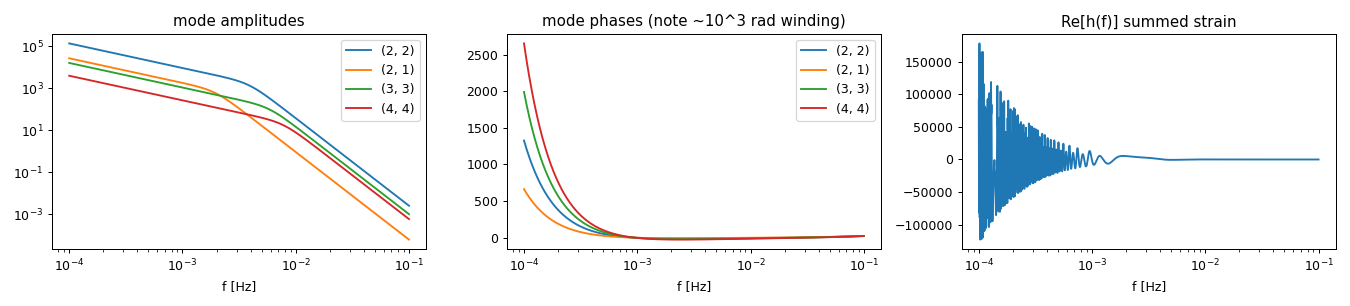

In [3]:
def sample_prior(n, rng):
    Mc = np.exp(rng.uniform(np.log(7.32e5), np.log(1.0e6), n))
    return [dict(Mc=Mc[i], q=rng.uniform(0.25, 1.0), chi1=rng.uniform(0, 0.99),
                 chi2=rng.uniform(0, 0.99), inc=rng.uniform(0, np.pi),
                 tc=rng.uniform(-50, 50)) for i in range(n)]

f = np.geomspace(1e-4, 1e-1, 1500)
rng = np.random.default_rng(0)
p0 = sample_prior(1, rng)[0]
m0 = generate_modes(p0, f)

fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
for lm in MODES:
    a, ph = m0[lm]
    ax[0].loglog(f, a, label=str(lm))
    ax[1].semilogx(f, ph, label=str(lm))
ax[0].set(title="mode amplitudes", xlabel="f [Hz]"); ax[0].legend()
ax[1].set(title="mode phases (note ~10^3 rad winding)", xlabel="f [Hz]"); ax[1].legend()
ax[2].semilogx(f, np.real(strain(p0, f))); ax[2].set(title="Re[h(f)] summed strain", xlabel="f [Hz]")
fig.tight_layout(); fig.savefig("fig_waveform.png", dpi=90); plt.close(fig)
print("(2,2) phase span:", round(np.ptp(m0[(2,2)][1]), 1), "rad")
from IPython.display import Image; Image("fig_waveform.png")


In [4]:
# ---- SVD utilities ----
def svd_basis(X):                       # full right-singular vectors (columns)
    _, s, Vh = np.linalg.svd(X, full_matrices=False)
    return Vh.conj().T, s

def project(X, V):                      # compress then decompress through first n cols
    return (X @ V) @ V.conj().T

def mismatch(a, b):
    inner = np.sum(a.conj() * b, axis=-1).real
    na = np.sqrt(np.sum(np.abs(a)**2, axis=-1)); nb = np.sqrt(np.sum(np.abs(b)**2, axis=-1))
    return 1 - inner / (na * nb)

# ---- build train / test sets ----
N_TRAIN, N_TEST = 800, 300
rng = np.random.default_rng(1)
train_p = sample_prior(N_TRAIN, rng)
test_p  = sample_prior(N_TEST, rng)

def stack_strain(plist):  return np.array([strain(p, f) for p in plist])
def stack_mode(plist, lm, attr):  # attr: 0=amp, 1=phase, 'h'=complex strain
    if attr == 'h':
        return np.array([(lambda a,ph:a*np.exp(1j*ph))(*generate_modes(p,f)[lm]) for p in plist])
    return np.array([generate_modes(p, f)[lm][attr] for p in plist])

Htr, Hte = stack_strain(train_p), stack_strain(test_p)
print("train strain matrix:", Htr.shape)


train strain matrix: (800, 1500)


## 3. Experiment A — SVD of the raw summed complex strain (baseline)

This is what your pipeline currently compresses. Watch how slowly the worst-case
mismatch falls — you need hundreds of basis vectors, and the *max* (the waveform that
matters for bias) lags far behind the mean.


In [5]:
Vraw, s_raw = svd_basis(Htr)
ns_strain = [5, 10, 20, 40, 80, 160, 320]
curve_A = []
for n in ns_strain:
    mm = mismatch(Hte, project(Hte, Vraw[:, :n]))
    curve_A.append(mm.max())
    print(f"  n={n:4d}   max mismatch={mm.max():.2e}   mean={mm.mean():.2e}")


  n=   5   max mismatch=9.86e-01   mean=8.53e-01
  n=  10   max mismatch=9.70e-01   mean=7.66e-01
  n=  20   max mismatch=9.45e-01   mean=6.16e-01
  n=  40   max mismatch=9.01e-01   mean=4.27e-01
  n=  80   max mismatch=7.45e-01   mean=1.98e-01
  n= 160   max mismatch=4.58e-01   mean=1.88e-02
  n= 320   max mismatch=2.89e-05   mean=9.99e-08


## 4. The heterodyne surprise — a fixed reference does NOT help the SVD

Heterodyning multiplies every waveform by the *same* phase vector `e^{-iΨ_fid(f)}`. In
matrix terms that is `X → X·D` with `D = diag(e^{-iΨ_fid})` **unitary**. Since
`X = U S Vᴴ ⇒ X D = U S (Vᴴ D)` and `VᴴD` still has orthonormal rows, the singular values
— and hence the truncation error at every `n` — are **identical**. We verify it numerically.

This is why relative binning's reference trick helps by allowing a *coarse frequency grid*,
**not** by shrinking an SVD/ROB basis. For DINGO's SVD layer, heterodyne ≈ no-op.


In [6]:
fid = dict(Mc=np.sqrt(7.32e5*1e6), q=0.6, chi1=0.5, chi2=0.5, inc=np.pi/3, tc=0.0)
fid_phase = {lm: generate_modes(fid, f)[lm][1] for lm in MODES}

# per-mode strain, with vs without a fixed heterodyne
for lm in [(2,2)]:
    Xtr  = stack_mode(train_p, lm, 'h')
    Xte  = stack_mode(test_p,  lm, 'h')
    D    = np.exp(-1j*fid_phase[lm])
    Vno,_  = svd_basis(Xtr)
    Vhet,_ = svd_basis(Xtr*D)
    print(f"mode {lm}:  n   no-het max     heterodyne max")
    for n in [20, 80, 160]:
        mm_no  = mismatch(Xte, project(Xte, Vno[:, :n])).max()
        mm_het = mismatch(Xte*D, project(Xte*D, Vhet[:, :n])).max()
        print(f"          {n:4d}  {mm_no:.3e}      {mm_het:.3e}")
print("\n=> identical: a fixed-reference heterodyne is unitary-invariant for the SVD.")


mode (2, 2):  n   no-het max     heterodyne max
            20  9.756e-01      9.756e-01
            80  8.741e-01      8.741e-01
           160  2.521e-05      2.521e-05

=> identical: a fixed-reference heterodyne is unitary-invariant for the SVD.


## 5. Experiment D — separate amplitude + unwrapped-phase SVD (the real win)

The unwrapped phase is `Ψ(f;θ) = Σ_k c_k(θ) g_k(f)` — a handful of *separable* terms
(chirp, PN coefficients, time). So as a function it is **low rank in the parameters**, and
the same is true of the amplitude. SVD each (real) array separately, reconstruct
`A·e^{iΨ}` per mode, then sum modes. A few components per mode reach machine precision.


In [7]:
# build per-mode amplitude / phase matrices and their bases
A_tr = {lm: stack_mode(train_p, lm, 0) for lm in MODES}
P_tr = {lm: stack_mode(train_p, lm, 1) for lm in MODES}
A_te = {lm: stack_mode(test_p,  lm, 0) for lm in MODES}
P_te = {lm: stack_mode(test_p,  lm, 1) for lm in MODES}
VA = {lm: svd_basis(A_tr[lm])[0] for lm in MODES}
VP = {lm: svd_basis(P_tr[lm])[0] for lm in MODES}

ns_ap = [2, 4, 6, 8, 12, 20]
curve_D = []
for n in ns_ap:
    Hrec = np.zeros_like(Hte)
    for lm in MODES:
        A_rec = project(A_te[lm], VA[lm][:, :n])
        P_rec = project(P_te[lm], VP[lm][:, :n])
        Hrec += np.real(A_rec) * np.exp(1j*np.real(P_rec))   # reconstruct, then sum
    mm = mismatch(Hte, Hrec)
    curve_D.append(mm.max())
    print(f"  n={n:3d} per mode (amp+phase)   max mismatch={mm.max():.2e}   mean={mm.mean():.2e}")


  n=  2 per mode (amp+phase)   max mismatch=1.25e+00   mean=8.13e-01
  n=  4 per mode (amp+phase)   max mismatch=6.20e-06   mean=1.93e-07
  n=  6 per mode (amp+phase)   max mismatch=2.50e-09   mean=8.00e-11
  n=  8 per mode (amp+phase)   max mismatch=8.24e-13   mean=3.01e-14


  n= 12 per mode (amp+phase)   max mismatch=4.44e-16   mean=-2.63e-17
  n= 20 per mode (amp+phase)   max mismatch=4.44e-16   mean=-2.96e-17


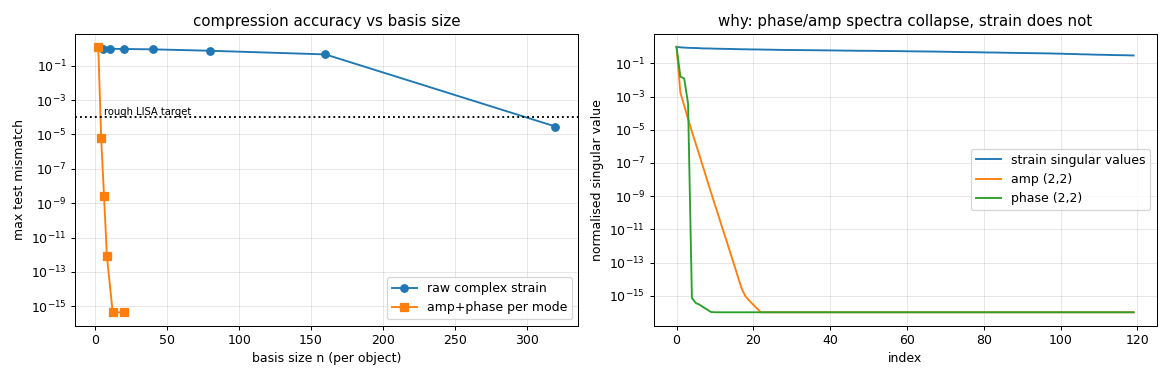

In [8]:
# ---- the money plot: basis size vs accuracy, and the singular-value spectra ----
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].semilogy(ns_strain, curve_A, 'o-', label="raw complex strain")
ax[0].semilogy(ns_ap, curve_D, 's-', label="amp+phase per mode")
ax[0].axhline(1e-4, ls=':', c='k'); ax[0].text(6, 1.3e-4, "rough LISA target", fontsize=8)
ax[0].set(xlabel="basis size n (per object)", ylabel="max test mismatch",
          title="compression accuracy vs basis size"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].semilogy(s_raw[:120]/s_raw[0], label="strain singular values")
ax[1].semilogy(svd_basis(A_tr[(2,2)])[1][:120]/svd_basis(A_tr[(2,2)])[1][0], label="amp (2,2)")
ax[1].semilogy(svd_basis(P_tr[(2,2)])[1][:120]/svd_basis(P_tr[(2,2)])[1][0], label="phase (2,2)")
ax[1].set(xlabel="index", ylabel="normalised singular value",
          title="why: phase/amp spectra collapse, strain does not"); ax[1].legend(); ax[1].grid(alpha=.3)
fig.tight_layout(); fig.savefig("fig_compare.png", dpi=90); plt.close(fig)
from IPython.display import Image; Image("fig_compare.png")


## 6. The coherent mode sum — where you leave the reduced domain

Experiment D reconstructs each mode (`A·e^{iΨ}`, **nonlinear**) on the full grid *before*
summing. That is the architectural cost we discussed: per-mode linear ops (LISA transfer,
time shift, `e^{-imφ}`) can stay in each mode's reduced space, but the **final coherent
sum over modes must happen on the full grid**. Below we confirm the summed reconstruction
of a single test waveform is essentially exact with only `n=8` amp/phase components/mode.


single-waveform mismatch at n=8/mode: 7.88e-15


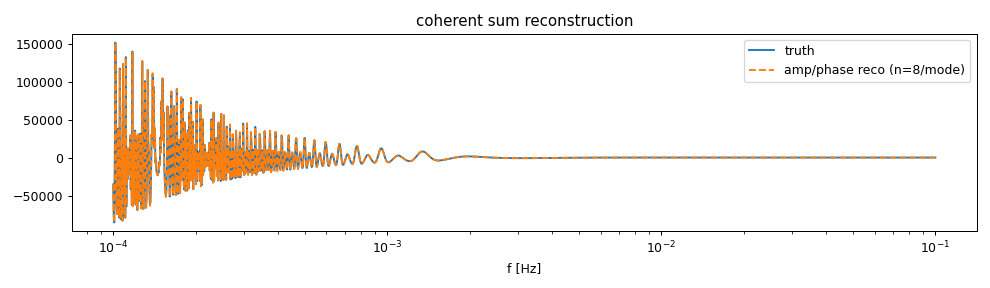

In [9]:
n = 8
p = test_p[0]
true = strain(p, f)
rec = np.zeros_like(true)
for lm in MODES:
    a  = project(generate_modes(p, f)[lm][0][None, :], VA[lm][:, :n])[0]
    ph = project(generate_modes(p, f)[lm][1][None, :], VP[lm][:, :n])[0]
    rec += np.real(a) * np.exp(1j*np.real(ph))
print(f"single-waveform mismatch at n={n}/mode: {float(mismatch(true[None], rec[None])[0]):.2e}")

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.semilogx(f, np.real(true), label="truth")
ax.semilogx(f, np.real(rec), '--', label=f"amp/phase reco (n={n}/mode)")
ax.set(title="coherent sum reconstruction", xlabel="f [Hz]"); ax.legend()
fig.tight_layout(); fig.savefig("fig_reco.png", dpi=90); plt.close(fig)
from IPython.display import Image; Image("fig_reco.png")


## 7. Pull *real* lisabeta waveforms (optional)

Everything above used a toy model so it runs anywhere. This section swaps in your actual
`LISAWaveformGenerator` (which wraps lisabeta) and repeats the key comparison on real
amp/phase waveforms. It is **guarded**: if lisabeta / dingo can't be imported, the cells
print setup notes and skip, leaving the toy results intact.

Pipeline faithfully reproduced here:
`generate_amp_phase` (sparse per-mode amp/phase) → **amp/phase-separate spline onto a
common grid** (the option-3 step, mirroring `process_transfer`) → per-mode amp/phase SVD →
reconstruct → coherent mode sum.


In [10]:
# ---- try to bring up the real generator ----
HAVE_LISABETA = False
real_gen = None
try:
    import sys
    # adjust if you run the notebook from somewhere other than the repo
    sys.path.insert(0, "..")
    from dingo.gw.domains import UniformFrequencyDomain
    from dingo.gw.waveform_generator.waveform_generator import LISAWaveformGenerator

    real_domain = UniformFrequencyDomain(f_min=1e-4, f_max=1e-1, delta_f=1e-5)
    real_gen = LISAWaveformGenerator(
        approximant="IMRPhenomHM",   # or "IMRPhenomD" (22 only) / "IMRPhenomXHM"
        domain=real_domain,
        f_ref=0.0,
        frozenLISA=False,
    )
    HAVE_LISABETA = True
    print("LISAWaveformGenerator constructed — will use REAL lisabeta waveforms.")
except Exception as e:
    print("lisabeta/dingo not available here -> skipping real-waveform section.")
    print("   reason:", repr(e))
    print("\n   To run this section, execute the notebook in your training env where")
    print("   `import lisabeta` works, from inside the dingo repo (so `import dingo` resolves).")


lisabeta/dingo not available here -> skipping real-waveform section.
   reason: ModuleNotFoundError("No module named 'lal'")

   To run this section, execute the notebook in your training env where
   `import lisabeta` works, from inside the dingo repo (so `import dingo` resolves).


In [11]:
# ---- parameter sampler with the LISA key names your config / generator expect ----
def sample_prior_lisa(n, rng):
    Mc = np.exp(rng.uniform(np.log(7.32e5), np.log(1.0e6), n))
    out = []
    for i in range(n):
        q = rng.uniform(0.25, 1.0)
        p = dict(
            chirp_mass=float(Mc[i]), mass_ratio=q,
            chi_1=rng.uniform(0, 0.99), chi_2=rng.uniform(0, 0.99),
            inc=rng.uniform(0, np.pi), phi=rng.uniform(0, 2*np.pi),
            # fixed extrinsic (DeltaFunctions in your prior)
            **{"lambda": 0.0}, beta=0.0, psi=1.239264, Deltat=0.0,
            dist=100.0, geocent_time=0.0, Lframe=False,
        )
        # aliases added by dingo's _add_lisa_parameter_aliases
        p["Mchirp"], p["q"], p["chi1"], p["chi2"] = p["chirp_mass"], q, p["chi_1"], p["chi_2"]
        out.append(p)
    return out

def real_modes(p):
    # returns {(l,m): (freq, amp, phase)} on lisabeta's sparse per-mode grid
    wf = real_gen.generate_amp_phase(dict(p))
    items = wf.items() if isinstance(wf, dict) and not {"amp", "phase"} <= set(wf) else [((2, 2), wf)]
    out = {}
    for key, d in items:
        lm = key if isinstance(key, tuple) else (2, 2)
        freq = np.asarray(d.get("freq", d.get("f"))).ravel()
        out[lm] = (freq, np.asarray(d["amp"]).ravel(), np.asarray(d["phase"]).ravel())
    return out

if HAVE_LISABETA:
    try:
        demo = real_modes(sample_prior_lisa(1, np.random.default_rng(0))[0])
        REAL_MODES = sorted(demo.keys())
        print("modes returned by lisabeta:", REAL_MODES)
        lm0 = REAL_MODES[0]
        print(f"  {lm0}: {len(demo[lm0][0])} grid points, "
              f"phase span {np.ptp(demo[lm0][2]):.0f} rad")
    except Exception as e:
        HAVE_LISABETA = False
        print("waveform generation failed -> skipping. reason:", repr(e))


In [12]:
# ---- amp/phase-separate interpolation onto a common grid (the option-3 step) ----
from scipy.interpolate import CubicSpline

f_real = np.geomspace(2e-4, 5e-2, 2000)   # common analysis grid

def interp_mode(freq, amp, phase, fc):
    # spline amplitude and (continuous) phase separately, zero-extrapolate amplitude
    inside = (fc >= freq[0]) & (fc <= freq[-1])
    a = np.zeros_like(fc); ph = np.zeros_like(fc)
    a[inside] = CubicSpline(freq, amp)(fc[inside])
    ph[inside] = CubicSpline(freq, phase)(fc[inside])
    return a, ph

def real_mode_arrays(plist, modes, fc):
    # -> dict lm -> (amp[n,Nf], phase[n,Nf]); and summed strain H[n,Nf]
    A = {lm: np.zeros((len(plist), len(fc))) for lm in modes}
    P = {lm: np.zeros((len(plist), len(fc))) for lm in modes}
    H = np.zeros((len(plist), len(fc)), dtype=np.complex128)
    for i, p in enumerate(plist):
        mm = real_modes(p)
        for lm in modes:
            if lm not in mm:
                continue
            a, ph = interp_mode(*mm[lm], fc)
            A[lm][i], P[lm][i] = a, ph
            H[i] += a * np.exp(1j * ph)
    return A, P, H

if HAVE_LISABETA:
    rng = np.random.default_rng(7)
    rp = sample_prior_lisa(120, rng)     # bump these up in your env
    tp = sample_prior_lisa(40, rng)
    Atr_r, Ptr_r, Htr_r = real_mode_arrays(rp, REAL_MODES, f_real)
    Ate_r, Pte_r, Hte_r = real_mode_arrays(tp, REAL_MODES, f_real)
    print("real train strain matrix:", Htr_r.shape, "| modes:", REAL_MODES)


In [13]:
# ---- repeat the comparison on REAL waveforms ----
if HAVE_LISABETA:
    # baseline: SVD of the raw summed complex strain
    Vr, sr = svd_basis(Htr_r)
    print("REAL raw summed-strain SVD:")
    for n in [5, 10, 20, 40, 80, 160]:
        if n < Vr.shape[1]:
            mm = mismatch(Hte_r, project(Hte_r, Vr[:, :n]))
            print(f"  n={n:4d}   max={mm.max():.2e}   mean={mm.mean():.2e}")

    # the win: per-mode amplitude + unwrapped-phase SVD
    VAr = {lm: svd_basis(Atr_r[lm])[0] for lm in REAL_MODES}
    VPr = {lm: svd_basis(Ptr_r[lm])[0] for lm in REAL_MODES}
    print("\nREAL per-mode amp+phase SVD:")
    for n in [2, 4, 6, 8, 12, 20]:
        Hrec = np.zeros_like(Hte_r)
        for lm in REAL_MODES:
            Hrec += (project(Ate_r[lm], VAr[lm][:, :n])
                     * np.exp(1j * project(Pte_r[lm], VPr[lm][:, :n])))
        mm = mismatch(Hte_r, Hrec)
        print(f"  n={n:3d}/mode   max={mm.max():.2e}   mean={mm.mean():.2e}")
else:
    print("Skipped (no lisabeta). The toy sections above already show the same conclusion.")


Skipped (no lisabeta). The toy sections above already show the same conclusion.


In [14]:
# ---- check the phase really is continuous / unwrapped on the sparse grid ----
if HAVE_LISABETA:
    p = sample_prior_lisa(1, np.random.default_rng(3))[0]
    mm = real_modes(p)
    fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
    for lm in REAL_MODES:
        fr, a, ph = mm[lm]
        ax[0].loglog(fr, a, '.-', ms=3, label=str(lm))
        ax[1].semilogx(fr, ph, '.-', ms=3, label=str(lm))
    ax[0].set(title="real lisabeta mode amplitudes", xlabel="f [Hz]"); ax[0].legend()
    ax[1].set(title="real lisabeta mode phases (must be unwrapped!)", xlabel="f [Hz]"); ax[1].legend()
    fig.tight_layout(); fig.savefig("fig_real.png", dpi=90); plt.close(fig)
    from IPython.display import Image
    display(Image("fig_real.png"))
else:
    print("Skipped (no lisabeta).")


Skipped (no lisabeta).


## 8. Playground

Things to try:

* **Widen the prior** (`sample_prior`: push `q` lower, spins higher, add `tc` range). Watch
  the raw-strain curve get *worse* while amp/phase barely moves.
* **Drop the phase basis size** in Experiment D to `n=2,3` to find where it breaks.
* **Add wrapping**: replace the analytic phase with `np.angle(A·e^{iΨ})` and try to SVD
  that — you'll see why **unwrapping is mandatory** before a phase SVD.
* **Tighten the target line** to `1e-6` (LISA SNR~10^3) and read off the basis sizes.
* Re-run `svd_basis` spectra for `(3,3)`/`(4,4)` to confirm higher modes are just as low-rank.


## 9. How this maps onto DINGO / your LISA code, and the caveats

* The model here mirrors `LISAWaveformGenerator.generate_amp_phase` (amp/phase per `(l,m)`)
  and the per-mode loop in `ProjectOntoSpaceDetectors.process_transfer`
  (`detector_transforms.py`), which already splines **amp_real / amp_imag / phase**
  separately and sums modes at the end. So an amp/phase SVD slots into the structure you
  already have: compress each mode's amplitude and unwrapped phase, decompress, apply the
  per-mode response, then sum.
* **Correction to earlier advice:** a *fixed-reference heterodyne* does **not** shrink the
  SVD basis (Section 4). The compression win comes from the **amp/phase decomposition**
  (Section 5), i.e. option *1a* — which is exactly the one that requires
  reconstruct-before-sum (Section 6).
* **Caveats for real waveforms (not in this toy):**
  - **Phase unwrapping** must be done on the native sparse grid before building the phase
    basis; a wrapped phase is discontinuous and will not compress.
  - Amplitude is complex once the **TDI transfer** is applied (`amp_real`, `amp_imag`):
    SVD those two real parts (as `process_transfer` already separates them), not `|A|`.
  - The phase basis should be built **after** removing only parameter-independent structure
    you can reproduce analytically; the residual θ-dependence is what the basis captures.
  - Validate with an **ASD-weighted** mismatch, not the flat one used here.
